In [ ]:
 # Cell 0: Setup
!apt-get install -y -q ffmpeg libsndfile1
!pip -q install torchaudio huggingface_hub "datasets<4.0.0" soundfile librosa einops omegaconf tqdm

import os
from pathlib import Path

if not Path("WavTokenizer").exists() and not Path("decoder").exists():
    !git clone -q https://github.com/jishengpeng/WavTokenizer.git
    os.chdir("WavTokenizer")
elif Path("WavTokenizer").exists():
    os.chdir("WavTokenizer")

import math, random, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import torchaudio
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Reading package lists...
Building dependency tree...
Reading state information...
libsndfile1 is already the newest version (1.0.31-2ubuntu0.2).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 33.5 MB/s eta 0:00:00
Device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
# Cell 1: Load WavTokenizer
from huggingface_hub import hf_hub_download
from decoder.pretrained import WavTokenizer

HF_REPO = "novateur/WavTokenizer"
CKPT_NAME = "WavTokenizer_small_600_24k_4096.ckpt"
ckpt_path = hf_hub_download(repo_id=HF_REPO, filename=CKPT_NAME)

# Find matching config (fail loudly if not found)
cfg_dir = Path("configs")
cfg_matches = sorted(cfg_dir.glob("*small*4096*.yaml"))
assert cfg_matches, f"No config matching *small*4096*.yaml in {cfg_dir}"
cfg_path = cfg_matches[0]
print(f"Config: {cfg_path}")

wavtokenizer = WavTokenizer.from_pretrained0802(str(cfg_path), ckpt_path).to(device).eval()
print("WavTokenizer loaded")

# Extract codebook (detached copy for safety)
vq0 = wavtokenizer.feature_extractor.encodec.quantizer.vq.layers[0]
codebook = vq0._codebook.embed.detach().clone()  # [M, D]
M, D = codebook.shape
print(f"Codebook: {M} codes × {D} dims")

decoder = wavtokenizer.feature_extractor.encodec.decoder

Config: configs/wavtokenizer_smalldata_frame40_3s_nq1_code4096_dim512_kmeans200_attn.yaml
WavTokenizer loaded
Codebook: 4096 codes × 512 dims


In [ ]:
# Cell 2: Setup LibriTTS streaming
from datasets import load_dataset

TARGET_SR = 24000
CHUNK_SEC = 3.0
CHUNK_LEN = int(TARGET_SR * CHUNK_SEC)

ds = load_dataset("parler-tts/libritts_r_filtered", "clean", split="train.clean.100", streaming=True)
ds = ds.shuffle(seed=42, buffer_size=1000)
ds_iter = iter(ds)

def get_audio_chunk(example):
    """Extract a random fixed-length audio chunk, resampled to TARGET_SR."""
    try:
        audio = example["audio"]
        sr = audio["sampling_rate"]
        wav = torch.tensor(audio["array"], dtype=torch.float32)
        if sr != TARGET_SR:
            wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
        if wav.numel() < CHUNK_LEN:
            return None
        start = random.randint(0, wav.numel() - CHUNK_LEN)
        return wav[start:start + CHUNK_LEN]
    except Exception:
        return None

# Quick test
test_wav = None
while test_wav is None:
    test_wav = get_audio_chunk(next(ds_iter))
print(f"Audio chunk shape: {test_wav.shape}")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

Audio chunk shape: torch.Size([72000])


In [ ]:
# Cell 3: Extract pre-VQ latents via hook
TARGET_LATENTS = 300_000
BATCH_SIZE = 8
MAX_PER_BATCH = 4096

captured_u = {}
def capture_hook(mod, inp, out):
    captured_u["u"] = out.detach()

hook_handle = vq0.project_in.register_forward_hook(capture_hook)

all_latents = []
bw_id = torch.tensor([0], device=device)
ds_iter = iter(ds.shuffle(seed=42, buffer_size=1000))
pbar = tqdm(total=TARGET_LATENTS, desc="Collecting latents")

wavtokenizer.eval()
with torch.no_grad():
    while sum(u.shape[0] for u in all_latents) < TARGET_LATENTS:
        wavs = []
        while len(wavs) < BATCH_SIZE:
            w = get_audio_chunk(next(ds_iter))
            if w is not None:
                wavs.append(w)

        captured_u.clear()
        _ = wavtokenizer.encode_infer(torch.stack(wavs).to(device), bandwidth_id=bw_id)

        if "u" not in captured_u:
            raise RuntimeError("Hook did not capture u")

        u = captured_u["u"].reshape(-1, D)  # [B, T, D] -> [B*T, D]
        if u.shape[0] > MAX_PER_BATCH:
            u = u[torch.randperm(u.shape[0])[:MAX_PER_BATCH]]

        all_latents.append(u.cpu())
        pbar.update(u.shape[0])

pbar.close()
hook_handle.remove()

U = torch.cat(all_latents)[:TARGET_LATENTS].float()
print(f"Collected latents: {U.shape}")

# Train/eval split
perm = torch.randperm(U.shape[0])
n_eval = min(15_000, int(0.05 * U.shape[0]))
U_train = U[perm[n_eval:]]
U_eval = U[perm[:n_eval]]

# Per-dimension normalization
u_mean = U_train.mean(0)
u_std = U_train.std(0).clamp(min=1e-4)
U_train_n = (U_train - u_mean) / u_std
U_eval_n = (U_eval - u_mean) / u_std

print(f"Train: {U_train_n.shape}, Eval: {U_eval_n.shape}")
print(f"Stats: mean_of_means={u_mean.mean():.4f}, mean_of_stds={u_std.mean():.4f}")

Collected latents: torch.Size([300000, 512])
Train: torch.Size([285000, 512]), Eval: torch.Size([15000, 512])
Stats: mean_of_means=0.0038, mean_of_stds=0.2856


In [ ]:
# === Diagnostics: shapes for a SIMPLE, correct decode ===
captured_u = {}
def capture_hook(mod, inp, out):
    captured_u["u"] = out.detach()

hook = vq0.project_in.register_forward_hook(capture_hook)

# build a single audio chunk
ds_iter_local = iter(ds.shuffle(seed=123, buffer_size=1000))
w = None
while w is None:
    w = get_audio_chunk(next(ds_iter_local))
wav = w.unsqueeze(0).to(device)  # [1, T_audio]

with torch.no_grad():
    _ = wavtokenizer.encode_infer(wav, bandwidth_id=bw_id)

hook.remove()

u = captured_u["u"]
print("captured u shape:", tuple(u.shape))  # key info

# try project_out on the captured tensor, in the simplest direct way
try:
    out = vq0.project_out(u)
    print("project_out(u) shape:", tuple(out.shape))
except Exception as e:
    print("project_out(u) FAILED:", repr(e))

# show decoder's expected input channels: first Conv1d weight is [out_ch, in_ch, k]
dec = wavtokenizer.feature_extractor.encodec.decoder
for name, p in dec.named_parameters():
    if p.dim() == 3:  # Conv1d weights
        print("decoder first conv weight:", name, tuple(p.shape))
        break


captured u shape: (1, 120, 512)
project_out(u) shape: (1, 120, 512)
decoder first conv weight: model.0.conv.conv.weight_g (512, 1, 1)


PCA top singular values: [3927.076    2675.4253   1635.9717    387.21082    91.96899    35.313297
   21.561201   17.100615]
B_pca: (512, 8)
[1/6] GN metric...


/usr/local/lib/python3.12/dist-packages/torch/backends/cudnn/__init__.py:145: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  torch._C._get_cudnn_allow_tf32(),


[2/6] GN metric...
[3/6] GN metric...
[4/6] GN metric...
[5/6] GN metric...
[6/6] GN metric...

Avg GN metric eigenvalues: [0.18474907 0.12522148 0.10350529 0.08470946 0.02693175 0.01493292
 0.00442426 0.00028396]
offdiag/diag ratio in PCA coords: 0.151


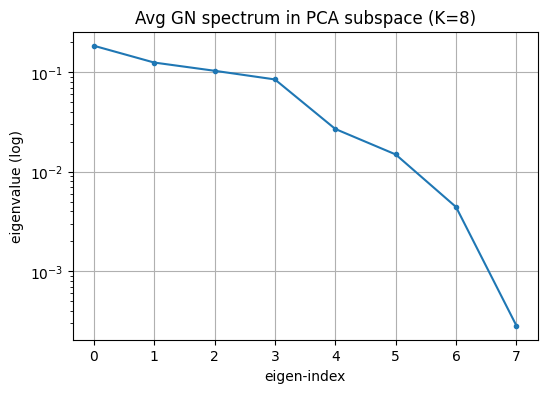

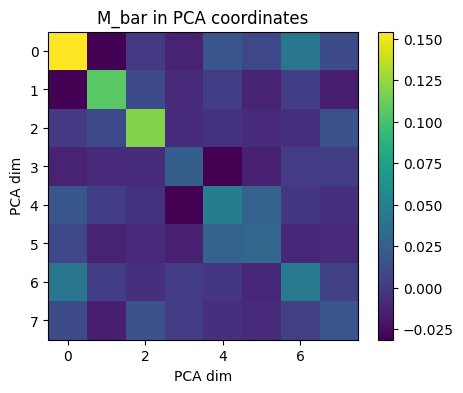

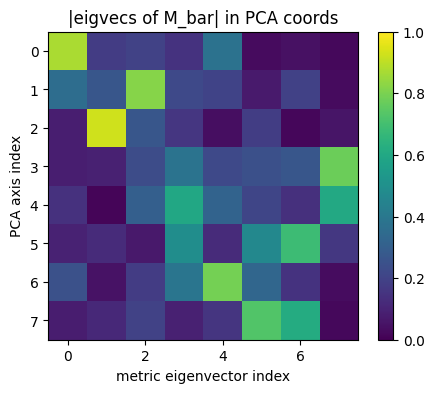

In [ ]:
PCA_N = min(50_000, U_train_n.shape[0])
idx = torch.randperm(U_train_n.shape[0])[:PCA_N]
X = U_train_n[idx].to(device)
X = X - X.mean(0, keepdim=True)

K_SUB = 8
_, S, V = torch.pca_lowrank(X, q=max(16, K_SUB + 8), center=False)
B_pca = V[:, :K_SUB].contiguous()    # [512, K_SUB]

print("PCA top singular values:", S[:K_SUB].detach().cpu().numpy())
print("B_pca:", tuple(B_pca.shape))

# ============================================================
# Cell 5: Differentiable decode + feature map
# ============================================================
u_mean_d = u_mean.to(device)
u_std_d  = u_std.to(device)

def decode_u_norm_seq(u_norm_seq):
    """
    u_norm_seq: [1, T, 512] normalized (project_in coordinates)
    returns waveform: [1, 1, T_audio]
    """
    u = u_norm_seq * u_std_d + u_mean_d          # [1, T, 512]
    u_out = vq0.project_out(u)                   # [1, T, 512]
    z = u_out.transpose(1, 2).contiguous()       # [1, 512, T]
    wav = decoder(z)                             # [1, 1, T_audio] typically
    return wav

mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=TARGET_SR,
    n_fft=1024,
    hop_length=256,
    n_mels=80,
    f_min=0.0,
    f_max=TARGET_SR/2,
    power=2.0,
).to(device)

# torchaudio quirk: move window to GPU if needed
if hasattr(mel, "spectrogram") and hasattr(mel.spectrogram, "window"):
    mel.spectrogram.window = mel.spectrogram.window.to(device)

def splice_frame(u_ctx, u_t, t):
    # u_ctx: [1, T, 512], u_t: [512]
    return torch.cat([u_ctx[:, :t, :], u_t.view(1, 1, -1), u_ctx[:, t+1:, :]], dim=1)

def feature_map(u_t_norm, u_ctx_norm, t):
    # Disable cuDNN inside this forward so jvp/double-backward works
    with torch.backends.cudnn.flags(enabled=False):
        u_seq = splice_frame(u_ctx_norm, u_t_norm, t)   # [1, T_ctx, 512]
        wav = decode_u_norm_seq(u_seq)                  # [1,1,T_audio]
        wav_ = wav[:, 0, :]                             # [1,T_audio]
        M = mel(wav_)                                   # [1,80,frames]
        M = torch.log(M + 1e-6)
        return M.reshape(-1)


# ============================================================
# Cell 6: Gauss–Newton metric in PCA subspace via JVP
# ============================================================
def gn_metric_subspace(u_t_norm, u_ctx_norm, t, B_sub):
    """
    Returns M_sub = (J_f(u) B)^T (J_f(u) B), size [K_SUB,K_SUB]
    """
    K = B_sub.shape[1]
    u0 = u_t_norm.detach().clone().requires_grad_(True)

    def f(u_vec):
        return feature_map(u_vec, u_ctx_norm, t)

    # sanity check: must depend on u0
    out = f(u0)
    assert out.requires_grad, "Graph broken: feature_map output does not require grad."

    cols = []
    for i in range(K):
        v = B_sub[:, i].detach()
        _, Jv = torch.autograd.functional.jvp(f, (u0,), (v,), create_graph=False, strict=True)
        cols.append(Jv)

    G = torch.stack(cols, dim=1)     # [F, K]
    M = G.t() @ G                    # [K, K], PSD
    M = 0.5 * (M + M.t())
    return M

# Choose contexts from the *eval* latents (i.i.d. pool)
T_CTX = 15
t_target = T_CTX // 2
N_SAMPLES = 6

starts = torch.randint(0, U_eval_n.shape[0] - T_CTX - 1, size=(N_SAMPLES,))
Ms = []

wavtokenizer.train()
decoder.train()
vq0.train()

for j, s in enumerate(starts.tolist()):
    u_ctx = U_eval_n[s:s+T_CTX].unsqueeze(0).to(device)   # [1,T_CTX,512]
    u_t   = u_ctx[0, t_target, :].clone()                 # [512]
    print(f"[{j+1}/{N_SAMPLES}] GN metric...")
    M_sub = gn_metric_subspace(u_t, u_ctx, t_target, B_pca.to(device))
    Ms.append(M_sub.cpu())

wavtokenizer.eval()
decoder.eval()
vq0.eval()


Ms = torch.stack(Ms, dim=0)      # [N,K,K]
M_bar = Ms.mean(dim=0)           # [K,K]

# eigenspectrum + "how diagonal in PCA coords?"
w, V = torch.linalg.eigh(M_bar)
w = torch.clamp(w, min=0)
idx = torch.argsort(w, descending=True)
w = w[idx]
V = V[:, idx]

offdiag = (M_bar - torch.diag(torch.diag(M_bar))).abs().mean().item()
diagmean = torch.diag(M_bar).abs().mean().item()
print("\nAvg GN metric eigenvalues:", w.numpy())
print(f"offdiag/diag ratio in PCA coords: {offdiag/(diagmean+1e-12):.3f}")

# Plots
plt.figure(figsize=(6,4))
plt.plot(w.numpy(), marker=".")
plt.yscale("log")
plt.title(f"Avg GN spectrum in PCA subspace (K={K_SUB})")
plt.xlabel("eigen-index")
plt.ylabel("eigenvalue (log)")
plt.grid(True)
plt.show()

plt.figure(figsize=(5,4))
plt.imshow(M_bar.numpy(), aspect="auto")
plt.colorbar()
plt.title("M_bar in PCA coordinates")
plt.xlabel("PCA dim")
plt.ylabel("PCA dim")
plt.show()

plt.figure(figsize=(5,4))
plt.imshow(np.abs(V.numpy()), aspect="auto", vmin=0, vmax=1)
plt.colorbar()
plt.title("|eigvecs of M_bar| in PCA coords")
plt.xlabel("metric eigenvector index")
plt.ylabel("PCA axis index")
plt.show()

=== Scale stats ===
     trace: mean=0.5448, std=0.0994, cv=0.182
  fro_norm: mean=0.2656, std=0.04903, cv=0.185
    logdet: mean=-30.17, std=1.405, cv=0.047
 cond_top4: mean=2.439, std=0.2295, cv=0.094

=== Dispersion ===
E||M - Mbar||_F / ||Mbar||_F = 0.23526226930883248

=== Subspace alignment (top-k) ===
align to mean: mean=0.998, min=0.998, max=0.999
pairwise align: mean=0.995, min=0.994, max=0.998


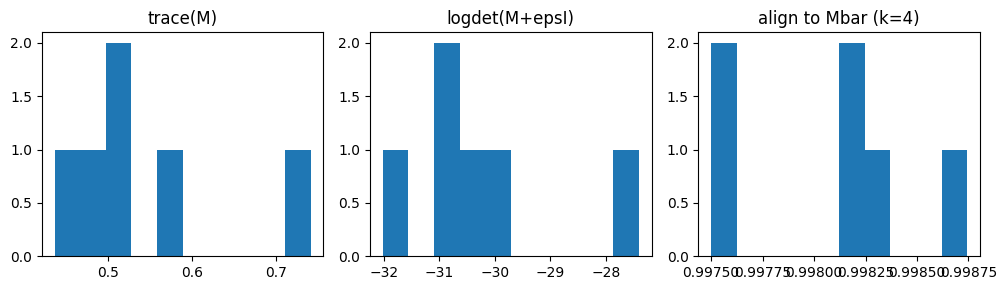

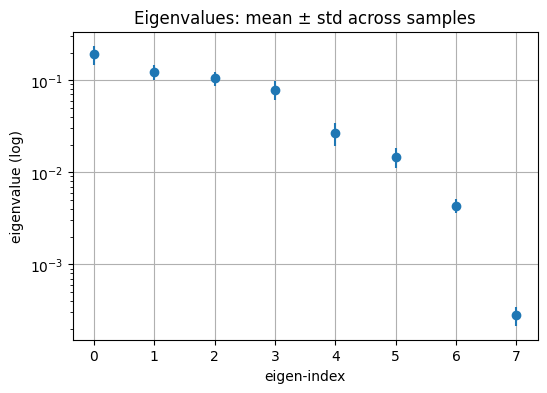

In [ ]:
# Cell: Is M_bar meaningful? Dispersion + subspace alignment diagnostics

import torch
import numpy as np
import matplotlib.pyplot as plt

eps = 1e-6
Ms_d = Ms.to(torch.float64)              # [N,K,K]
Mbar_d = M_bar.to(torch.float64)         # [K,K]
N, K, _ = Ms_d.shape

def eig_sorted(M):
    w, V = torch.linalg.eigh(M)
    w = torch.clamp(w, min=0)
    idx = torch.argsort(w, descending=True)
    return w[idx], V[:, idx]

# Per-sample summaries
traces = torch.einsum('nii->n', Ms_d)  # trace
fro_norms = torch.linalg.norm(Ms_d.reshape(N, -1), dim=1)

# logdet(M + eps I)
I = torch.eye(K, dtype=torch.float64)
logdets = torch.stack([torch.logdet(Ms_d[i] + eps*I) for i in range(N)])

# eigenvalues per sample
evals = []
for i in range(N):
    w, _ = eig_sorted(Ms_d[i])
    evals.append(w)
evals = torch.stack(evals, dim=0)  # [N,K]

# Condition number on top-k active subspace (avoid tiny tail eigenvalues)
k_active = min(4, K)
cond_topk = evals[:, 0] / (evals[:, k_active-1] + 1e-12)

# Dispersion around mean
diff = Ms_d - Mbar_d
rel_frob_disp = (torch.linalg.norm(diff.reshape(N, -1), dim=1).mean()
                 / (torch.linalg.norm(Mbar_d) + 1e-12))

print("=== Scale stats ===")
for name, x in [("trace", traces), ("fro_norm", fro_norms), ("logdet", logdets), (f"cond_top{k_active}", cond_topk)]:
    x_np = x.cpu().numpy()
    print(f"{name:>10s}: mean={x_np.mean():.4g}, std={x_np.std():.4g}, cv={x_np.std()/(abs(x_np.mean())+1e-12):.3f}")

print("\n=== Dispersion ===")
print("E||M - Mbar||_F / ||Mbar||_F =", float(rel_frob_disp))

# Subspace alignment
wbar, Vbar = eig_sorted(Mbar_d)
Vbar_k = Vbar[:, :k_active]  # [K,k]

align_to_bar = []
pair_align = []

# alignment metric: (||V_i^T V_j||_F^2)/k in [0,1]
def subspace_align(Va, Vb):
    return float((torch.linalg.norm(Va.t() @ Vb, ord='fro')**2 / Va.shape[1]).cpu())

Vi_list = []
for i in range(N):
    wi, Vi = eig_sorted(Ms_d[i])
    Vi_k = Vi[:, :k_active]
    Vi_list.append(Vi_k)
    align_to_bar.append(subspace_align(Vi_k, Vbar_k))

for i in range(N):
    for j in range(i+1, N):
        pair_align.append(subspace_align(Vi_list[i], Vi_list[j]))

align_to_bar = np.array(align_to_bar)
pair_align = np.array(pair_align)

print("\n=== Subspace alignment (top-k) ===")
print(f"align to mean: mean={align_to_bar.mean():.3f}, min={align_to_bar.min():.3f}, max={align_to_bar.max():.3f}")
if len(pair_align) > 0:
    print(f"pairwise align: mean={pair_align.mean():.3f}, min={pair_align.min():.3f}, max={pair_align.max():.3f}")

# Plots (optional)
plt.figure(figsize=(10,3))
plt.subplot(1,3,1); plt.hist(traces.cpu().numpy(), bins=10); plt.title("trace(M)")
plt.subplot(1,3,2); plt.hist(logdets.cpu().numpy(), bins=10); plt.title("logdet(M+epsI)")
plt.subplot(1,3,3); plt.hist(align_to_bar, bins=10); plt.title(f"align to Mbar (k={k_active})")
plt.tight_layout(); plt.show()

# Also show eigenvalue variability
plt.figure(figsize=(6,4))
plt.errorbar(np.arange(K), evals.mean(0).cpu().numpy(), yerr=evals.std(0).cpu().numpy(), fmt='o')
plt.yscale('log')
plt.title("Eigenvalues: mean ± std across samples")
plt.xlabel("eigen-index")
plt.ylabel("eigenvalue (log)")
plt.grid(True)
plt.show()


In [ ]:
# ============================================================
# PREP CELL: choose distortion regime and produce Z_train/Z_eval
# ============================================================
import math, torch
import torchaudio
import numpy as np

# ----------------------------
# USER CHOICE
# ----------------------------
REGIME = "mel"   # "pca" or "mel"
K_SUB  = 5       # your BA/NERD dimension (keep same as below)
N_METRIC_SAMPLES = 500   # contexts used to estimate M_bar (10-30 is fine)
T_CTX = 15
t_target = T_CTX // 2

print(f"[prep] REGIME={REGIME}  K_SUB={K_SUB}")

# ----------------------------
# 1) Fit PCA basis on normalized latents U_train_n (same as you already do)
# ----------------------------
@torch.no_grad()
def fit_pca_basis(U_train_n: torch.Tensor, k: int, center: bool = True, device=None):
    if device is None: device = U_train_n.device
    X = U_train_n.to(device).float()
    mu = X.mean(0) if center else torch.zeros(X.shape[1], device=device, dtype=X.dtype)
    Xc = X - mu
    _, S, V = torch.pca_lowrank(Xc, q=k, center=False)
    B = V[:, :k].contiguous()  # (D,k) orthonormal
    return B, mu, S[:k]

@torch.no_grad()
def project(U_n: torch.Tensor, B: torch.Tensor, mu: torch.Tensor):
    return ((U_n.to(B.device).float() - mu) @ B).contiguous()

B_pca, mu_pca, S_top = fit_pca_basis(U_train_n, k=K_SUB, center=True, device=device)

# base PCA coordinates (not yet metric-whitened)
Z_train_pca = project(U_train_n, B_pca, mu_pca).to(device)
Z_eval_pca  = project(U_eval_n,  B_pca, mu_pca).to(device)

print("[prep] Z_train_pca:", tuple(Z_train_pca.shape), "Z_eval_pca:", tuple(Z_eval_pca.shape))

# ----------------------------
# 2) Build whitening W depending on regime
#    - REGIME="pca": W = I
#    - REGIME="mel": estimate M_bar in PCA coords, then W = sqrt(Lambda) V^T
# ----------------------------
W = torch.eye(K_SUB, device=device)

if REGIME == "mel":
    # ---- differentiable decode + log-mel feature map (same simple shape contract) ----
    decoder = wavtokenizer.feature_extractor.encodec.decoder
    vq0 = wavtokenizer.feature_extractor.encodec.quantizer.vq.layers[0]

    u_mean_d = u_mean.to(device)
    u_std_d  = u_std.to(device)

    def decode_u_norm_seq(u_norm_seq):
        # u_norm_seq: [1, T, 512] normalized, in project_in coordinates
        u = u_norm_seq * u_std_d + u_mean_d          # [1, T, 512]
        u_out = vq0.project_out(u)                   # [1, T, 512]
        z = u_out.transpose(1, 2).contiguous()       # [1, 512, T]
        return decoder(z)

    mel = torchaudio.transforms.MelSpectrogram(
        sample_rate=TARGET_SR,
        n_fft=1024,
        hop_length=256,
        n_mels=80,
        f_min=0.0,
        f_max=TARGET_SR/2,
        power=2.0,
    ).to(device)
    if hasattr(mel, "spectrogram") and hasattr(mel.spectrogram, "window"):
        mel.spectrogram.window = mel.spectrogram.window.to(device)

    def splice_frame(u_ctx, u_t, t):
        return torch.cat([u_ctx[:, :t, :], u_t.view(1, 1, -1), u_ctx[:, t+1:, :]], dim=1)

    def feature_map_from_u(u_t_norm, u_ctx_norm, t):
        # crucial: disable cudnn so jvp/double-backward works with RNNs
        with torch.backends.cudnn.flags(enabled=False):
            u_seq = splice_frame(u_ctx_norm, u_t_norm, t)  # [1,T,512]
            wav = decode_u_norm_seq(u_seq)                 # [1,1,T_audio]
            wav_ = wav[:, 0, :]                            # [1,T_audio]
            M = mel(wav_)                                  # [1,80,frames]
            M = torch.log(M + 1e-6)
            return M.reshape(-1)

    def gn_metric_subspace_one(u_ctx_norm, B_sub, t):
        # u_ctx_norm: [1,T,512] normalized context
        u0 = u_ctx_norm[0, t, :].detach().clone().requires_grad_(True)

        def f(u_vec):
            return feature_map_from_u(u_vec, u_ctx_norm, t)

        # sanity check
        out = f(u0)
        assert out.requires_grad, "graph broken (feature_map output has no grad)."

        cols = []
        for i in range(B_sub.shape[1]):
            v = B_sub[:, i].detach()
            _, Jv = torch.autograd.functional.jvp(f, (u0,), (v,), create_graph=False, strict=True)
            cols.append(Jv)
        G = torch.stack(cols, dim=1)  # [F,k]
        M = G.t() @ G                 # [k,k]
        return 0.5 * (M + M.t())

    # ---- estimate M_bar in PCA coordinates (k x k) ----
    # IMPORTANT: B_sub here is the PCA basis itself (512,k)
    # because we want M in PCA coords (z = B^T(u-mu)).
    # For jvp, we need directions in original 512-D: B_pca columns.
    B_sub = B_pca.to(device)

    # draw random contexts from U_eval_n (normalized 512D points)
    # We treat them as an i.i.d. pool; context is just a splice trick for decoder locality.
    starts = torch.randint(0, U_eval_n.shape[0] - T_CTX - 1, size=(N_METRIC_SAMPLES,))
    Ms = []
    print(f"[prep] estimating M_bar with {N_METRIC_SAMPLES} contexts ...")
    for j, s in enumerate(starts.tolist(), 1):
        u_ctx = U_eval_n[s:s+T_CTX].unsqueeze(0).to(device)   # [1,T,512]
        Mj = gn_metric_subspace_one(u_ctx, B_sub, t_target)
        Ms.append(Mj.detach())
        print(f"  done {j}/{N_METRIC_SAMPLES}")

    M_bar = torch.stack(Ms, dim=0).mean(dim=0)   # [k,k]
    M_bar = 0.5 * (M_bar + M_bar.t())

    # eigendecomposition and whitening transform W = sqrt(Lambda) V^T
    w, V = torch.linalg.eigh(M_bar)
    w = torch.clamp(w, min=1e-12)
    idx = torch.argsort(w, descending=True)
    w = w[idx]
    V = V[:, idx]

    W = torch.diag(torch.sqrt(w)) @ V.t()        # [k,k]
    print("[prep] M_bar eigs:", w.detach().cpu().numpy())
    offdiag = (M_bar - torch.diag(torch.diag(M_bar))).abs().mean().item()
    diagmean = torch.diag(M_bar).abs().mean().item()
    print(f"[prep] offdiag/diag in PCA coords: {offdiag/(diagmean+1e-12):.3f}")

elif REGIME == "pca":
    print("[prep] Using plain PCA Euclidean distortion (W=I).")
else:
    raise ValueError("REGIME must be 'pca' or 'mel'")

# ----------------------------
# 3) Apply final transform: z_final = z_pca @ W^T
#    Then ||z_final - z_final'||^2 equals the chosen quadratic distortion.
# ----------------------------
@torch.no_grad()
def apply_W(Z_pca, W):
    return (Z_pca @ W.t()).contiguous()

Z_train = apply_W(Z_train_pca, W).float()
Z_eval  = apply_W(Z_eval_pca,  W).float()

print("[prep] Z_train:", tuple(Z_train.shape), "Z_eval:", tuple(Z_eval.shape))

# ----------------------------
# 4) Codebook reference in same space
#    codebook is in *pre-normalization* space, so normalize with (u_mean,u_std) first,
#    then apply same PCA projection and W
# ----------------------------
@torch.no_grad()
def codebook_to_Z(codebook, u_mean, u_std, B_pca, mu_pca, W):
    codebook_n = (codebook.float().cpu() - u_mean.cpu()) / u_std.cpu()
    codebook_n = codebook_n.to(B_pca.device)
    Z_cb_pca = (codebook_n - mu_pca) @ B_pca          # [M,k]
    Z_cb = Z_cb_pca @ W.t()
    return Z_cb.contiguous()

Z_codebook = codebook_to_Z(codebook, u_mean, u_std, B_pca.to(device), mu_pca.to(device), W)
print("[prep] Z_codebook:", tuple(Z_codebook.shape))

# ----------------------------
# 5) What to change in your BA/NERD calls
# ----------------------------
if REGIME == "mel":
    print("\n[prep] IMPORTANT: for REGIME='mel', DO NOT add Euclidean residual floor.")
    print("       Set: use_resid_floor=False and resid_floor=0.0 in BA sweep.")
    print("       And in NERD reporting, do NOT do D_full = D_sub + floor.")
    floor = 0.0
else:
    # your existing residual floor (Euclidean) remains meaningful only for REGIME='pca'
    # (keep your existing residual_floor_mse call if you want)
    pass


[prep] REGIME=mel  K_SUB=5
[prep] Z_train_pca: (285000, 5) Z_eval_pca: (15000, 5)
[prep] estimating M_bar with 500 contexts ...
  done 1/500
  done 2/500
  done 3/500
  done 4/500
  done 5/500
  done 6/500
  done 7/500
  done 8/500
  done 9/500
  done 10/500
  done 11/500
  done 12/500
  done 13/500
  done 14/500
  done 15/500
  done 16/500
  done 17/500
  done 18/500
  done 19/500
  done 20/500
  done 21/500
  done 22/500
  done 23/500
  done 24/500
  done 25/500
  done 26/500
  done 27/500
  done 28/500
  done 29/500
  done 30/500
  done 31/500
  done 32/500
  done 33/500
  done 34/500
  done 35/500
  done 36/500
  done 37/500
  done 38/500
  done 39/500
  done 40/500
  done 41/500
  done 42/500
  done 43/500
  done 44/500
  done 45/500
  done 46/500
  done 47/500
  done 48/500
  done 49/500
  done 50/500
  done 51/500
  done 52/500
  done 53/500
  done 54/500
  done 55/500
  done 56/500
  done 57/500
  done 58/500
  done 59/500
  done 60/500
  done 61/500
  done 62/500
  done 63/500

In [ ]:
print("=== BLOCK A: PREP fingerprints ===")
print("REGIME:", REGIME)
print("U_eval_n:", tuple(U_eval_n.shape), U_eval_n.dtype, U_eval_n.device)
print("Z_eval:", tuple(Z_eval.shape), Z_eval.dtype, Z_eval.device)

print("B_pca:", tuple(B_pca.shape), B_pca.dtype, B_pca.device)
print("mu_pca:", tuple(mu_pca.shape), mu_pca.dtype, mu_pca.device)
print("W:", tuple(W.shape), W.dtype, W.device)

# numeric fingerprints (stable-ish)
def fp(x, name):
    x = x.detach().float().flatten()
    print(f"{name}: mean={x.mean().item():+.6f} std={x.std().item():.6f} "
          f"min={x.min().item():+.6f} max={x.max().item():+.6f}")

fp(U_eval_n[:1000], "U_eval_n[:1000]")
fp(Z_eval[:1000], "Z_eval[:1000]")
fp(B_pca, "B_pca")
fp(mu_pca, "mu_pca")
fp(W, "W")


=== BLOCK A: PREP fingerprints ===
REGIME: mel
U_eval_n: (15000, 512) torch.float32 cpu
Z_eval: (15000, 5) torch.float32 cuda:0
B_pca: (512, 5) torch.float32 cuda:0
mu_pca: (512,) torch.float32 cuda:0
W: (5, 5) torch.float32 cuda:0
U_eval_n[:1000]: mean=-0.000649 std=1.015868 min=-4.175755 max=+5.242714
Z_eval[:1000]: mean=+0.009227 std=3.687825 min=-18.431833 max=+17.087807
B_pca: mean=+0.001608 std=0.044174 min=-0.343071 max=+0.495294
mu_pca: mean=-0.000000 std=0.000000 min=-0.000001 max=+0.000002
W: mean=+0.017886 std=0.131820 min=-0.274305 max=+0.352160


In [ ]:
print("\n=== BLOCK B: reconstruct Z_eval directly ===")
s = 1234
u = U_eval_n[s].to(device).float()   # normalized point

z_pca_direct = (u - mu_pca) @ B_pca          # (k,)
z_final_direct = z_pca_direct @ W.t()        # (k,)

print("z_final_direct[:5]:", z_final_direct[:5].detach().cpu().numpy())
print("Z_eval[s][:5]:      ", Z_eval[s][:5].detach().cpu().numpy())
print("||direct - Z_eval[s]||:", torch.norm(z_final_direct - Z_eval[s]).item())



=== BLOCK B: reconstruct Z_eval directly ===
z_final_direct[:5]: [-7.877667   -1.7617317   2.598999    0.47798562  0.01416878]
Z_eval[s][:5]:       [-7.877666   -1.7617315   2.598999    0.47798556  0.01416878]
||direct - Z_eval[s]||: 9.848321269601001e-07


Initializing Y with kmeans++ ...
kmeans++ init: picked 512/8192 centers
kmeans++ init: picked 1024/8192 centers
kmeans++ init: picked 1536/8192 centers
kmeans++ init: picked 2048/8192 centers
kmeans++ init: picked 2560/8192 centers
kmeans++ init: picked 3072/8192 centers
kmeans++ init: picked 3584/8192 centers
kmeans++ init: picked 4096/8192 centers
kmeans++ init: picked 4608/8192 centers
kmeans++ init: picked 5120/8192 centers
kmeans++ init: picked 5632/8192 centers
kmeans++ init: picked 6144/8192 centers
kmeans++ init: picked 6656/8192 centers
kmeans++ init: picked 7168/8192 centers
kmeans++ init: picked 7680/8192 centers

=== beta = 0.2 ===

=== beta = 0.3 ===

=== beta = 0.4 ===

=== beta = 0.5 ===

=== beta = 0.7 ===

=== beta = 1 ===

=== beta = 1.4 ===

=== beta = 2 ===

=== beta = 3 ===

=== beta = 4 ===
   beta     R_bits         D     M  update_support
0   0.2   8.443749  7.246092  8192            True
1   0.3   9.364467  4.612709  8192            True
2   0.4  10.033487  3.2

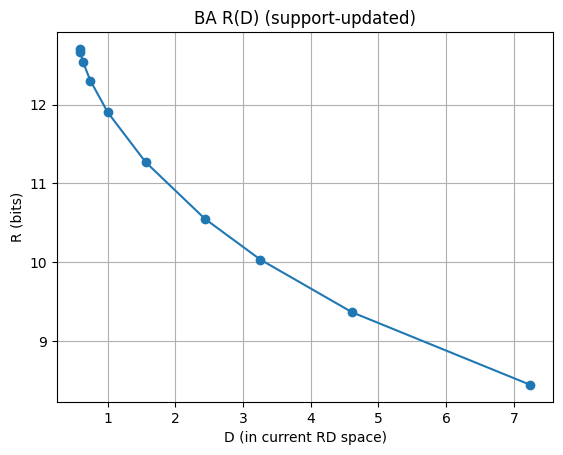

,beta,R_bits,D,M,update_support
0,4.0,12.705363,0.586071,8192,True
1,3.0,12.667302,0.594693,8192,True
2,2.0,12.544945,0.634395,8192,True
3,1.4,12.304509,0.744818,8192,True
4,1.0,11.899667,1.003336,8192,True
5,0.7,11.269192,1.561765,8192,True
6,0.5,10.550756,2.436926,8192,True
7,0.4,10.033487,3.256261,8192,True
8,0.3,9.364467,4.612709,8192,True
9,0.2,8.443749,7.246092,8192,True


In [ ]:
# ============================
# BA on continuous support with support+weight updates (soft Lloyd / deterministic annealing)
# Cleaned + corrected:
#  - Removes residual_floor_mse usage (misleading for non-Euclidean / even for PCA reporting)
#  - Fixes a few numerical details (clamp, stable normalizations)
#  - Adds optional "fixed-support" mode (e.g. codebook) by setting update_support=False
#  - Makes the output columns unambiguous: D (in current space), R_bits
#  - Keeps everything torch.no_grad() and chunked
# ============================

import math, torch, numpy as np, pandas as pd

LN2 = math.log(2.0)

# ----------------------------
# KMeans++ init for Y (helps vs random subset)
# ----------------------------
@torch.no_grad()
def kmeanspp_init(Z: torch.Tensor, M: int, seed: int = 0, chunk: int = 8192, verbose: bool = True):
    """
    KMeans++ seeding in low-dim; Z: (N,k). Returns Y0: (M,k).
    Complexity is O(MN) so use moderate M if you do this.
    """
    device = Z.device
    Z = Z.float()
    N, k = Z.shape
    g = torch.Generator(device=device)
    g.manual_seed(seed)

    first = torch.randint(0, N, (1,), generator=g, device=device).item()
    Y = torch.empty((M, k), device=device, dtype=torch.float32)
    Y[0] = Z[first]

    dmin = torch.full((N,), float("inf"), device=device, dtype=torch.float32)

    for m in range(1, M):
        c = Y[m-1:m]  # (1,k)
        # update min dist to any chosen center so far
        for s in range(0, N, chunk):
            z = Z[s:s+chunk]
            d = ((z - c) ** 2).sum(-1)
            dmin[s:s+chunk] = torch.minimum(dmin[s:s+chunk], d)

        probs = dmin.clamp(min=1e-12)
        probs = probs / probs.sum()
        idx = torch.multinomial(probs, num_samples=1, generator=g).item()
        Y[m] = Z[idx]

        if verbose and (m % 512 == 0):
            print(f"kmeans++ init: picked {m}/{M} centers")

    return Y.contiguous()


# ----------------------------
# Core BA pass over data: compute q update, distortion, mutual information
# ----------------------------
@torch.no_grad()
def _ba_pass_stats(Z: torch.Tensor, Y: torch.Tensor, logq: torch.Tensor, beta: float, chunk_N: int):
    """
    Z: (N,k), Y: (M,k), logq: (M,), beta: float
    Returns:
      q_new: (M,)
      D: float, distortion E[d(Z,Y)] under posterior p(j|z)
      R_bits: float, I(Z;J)/log 2
      num: (M,k), den: (M,) for centroid update
    """
    device = Z.device
    Z = Z.float()
    Y = Y.float()
    logq = logq.float()
    beta = float(beta)

    N, k = Z.shape
    M = Y.shape[0]

    y2 = (Y * Y).sum(-1)  # (M,)
    q_acc = torch.zeros((M,), device=device, dtype=torch.float32)
    den   = torch.zeros((M,), device=device, dtype=torch.float32)
    num   = torch.zeros((M, k), device=device, dtype=torch.float32)

    D_sum = 0.0
    I_sum = 0.0

    for s in range(0, N, chunk_N):
        z = Z[s:s+chunk_N]                      # (B,k)
        z2 = (z * z).sum(-1, keepdim=True)      # (B,1)
        # squared distances: ||z||^2 + ||y||^2 - 2 z·y
        d = (z2 + y2.unsqueeze(0) - 2.0 * (z @ Y.t()))
        d = d.clamp(min=0.0)                    # (B,M)

        logits = logq.unsqueeze(0) - beta * d   # (B,M)
        lse = torch.logsumexp(logits, dim=1, keepdim=True)
        logp = logits - lse
        p = torch.exp(logp)                     # (B,M)

        q_acc += p.sum(0)
        den   += p.sum(0)
        num   += p.t() @ z

        D_sum += (p * d).sum().item()
        I_sum += (p * (logp - logq.unsqueeze(0))).sum().item()

    q_new = (q_acc / float(N)).clamp(min=1e-30)
    D = D_sum / float(N)
    R_bits = (I_sum / float(N)) / LN2
    return q_new, float(D), float(R_bits), num, den


# ----------------------------
# BA with optional support updates (soft Lloyd)
# ----------------------------
@torch.no_grad()
def ba_support(
    Z: torch.Tensor,                 # (N,k) empirical source (uniform)
    beta: float,
    M: int = None,                   # number of support points if Y_init not provided
    Y_init: torch.Tensor = None,     # (M,k) optional
    logq_init: torch.Tensor = None,  # (M,) optional
    outer_iters: int = 25,
    inner_iters: int = 5,
    tol_q: float = 1e-6,
    chunk_N: int = 2048,
    update_support: bool = True,     # if False => fixed support BA on Y_init
    verbose: bool = False,
):
    """
    If update_support=True:
      Alternates:
        (1) BA updates of q for fixed Y
        (2) centroid updates of Y under posterior p(j|z)
    If update_support=False:
      Runs BA updates only (fixed Y).
    """
    device = Z.device
    Z = Z.float()
    N, k = Z.shape

    if Y_init is None:
        assert M is not None, "Provide M if Y_init is None"
        idx = torch.randperm(N, device=device)[:M]
        Y = Z[idx].clone().contiguous()
    else:
        Y = Y_init.to(device).float().contiguous()
        M = Y.shape[0]
        assert Y.shape[1] == k

    if logq_init is None:
        logq = torch.full((M,), -math.log(M), device=device, dtype=torch.float32)
    else:
        logq = logq_init.to(device).float().contiguous()
        logq = logq - torch.logsumexp(logq, dim=0)

    last_D = None

    for t in range(outer_iters):
        # (1) BA updates for q at fixed support
        for _ in range(inner_iters):
            q_new, D, R_bits, num, den = _ba_pass_stats(Z, Y, logq, beta, chunk_N)
            q_old = torch.exp(logq)
            delta = torch.max(torch.abs(q_new - q_old)).item()
            logq = torch.log(q_new)
            if delta < tol_q:
                break

        # (2) Support update (optional)
        if update_support:
            Y = (num / (den.unsqueeze(1) + 1e-12)).contiguous()

        if verbose:
            print(f"[outer {t:02d}] beta={beta:g}  D={D:.6f}  R={R_bits:.4f} bits  max|Δq|={delta:.2e}")

        if last_D is not None and abs(last_D - D) < 1e-10 and delta < 1e-6:
            break
        last_D = D

        if not update_support:
            # if support fixed, no point doing many outer loops; BA already converges via inner loops
            # but keep structure for consistency
            pass

    # final stats at end
    q_new, D, R_bits, _, _ = _ba_pass_stats(Z, Y, logq, beta, chunk_N)
    return {"Y": Y, "q": q_new, "logq": torch.log(q_new), "D": float(D), "R_bits": float(R_bits)}


# ----------------------------
# Beta sweep with warm-start continuation
# ----------------------------
@torch.no_grad()
def sweep_betas(
    Z_src: torch.Tensor,
    betas,
    M: int = 4096,
    init: str = "kmeans++",          # "kmeans++" or "subset"
    seed: int = 0,
    outer_iters: int = 25,
    inner_iters: int = 5,
    chunk_N: int = 2048,
    update_support: bool = True,
    Y_fixed: torch.Tensor = None,    # if provided, uses fixed support (overrides init)
    verbose: bool = False,
):
    device = Z_src.device
    Z_src = Z_src.float()

    if Y_fixed is not None:
        Y0 = Y_fixed.to(device).float().contiguous()
        logq0 = torch.full((Y0.shape[0],), -math.log(Y0.shape[0]), device=device)
        Y_prev, logq_prev = Y0, logq0
        print(f"Using fixed support Y_fixed with M={Y0.shape[0]}")
    else:
        if init == "kmeans++":
            print("Initializing Y with kmeans++ ...")
            Y0 = kmeanspp_init(Z_src, M=M, seed=seed, verbose=True)
        else:
            idx = torch.randperm(Z_src.shape[0], device=device)[:M]
            Y0 = Z_src[idx].clone().contiguous()
        Y_prev, logq_prev = Y0, None

    rows = []
    for b in betas:
        b = float(b)
        print(f"\n=== beta = {b:g} ===")
        out = ba_support(
            Z=Z_src,
            beta=b,
            M=Y_prev.shape[0],
            Y_init=Y_prev,
            logq_init=logq_prev,
            outer_iters=outer_iters,
            inner_iters=inner_iters,
            tol_q=1e-6,
            chunk_N=chunk_N,
            update_support=update_support if (Y_fixed is None) else False,
            verbose=verbose,
        )
        rows.append({
            "beta": b,
            "R_bits": out["R_bits"],
            "D": out["D"],
            "M": int(out["Y"].shape[0]),
            "update_support": bool(update_support if (Y_fixed is None) else False),
        })
        Y_prev, logq_prev = out["Y"], out["logq"]

    return pd.DataFrame(rows)


# ============================
# RUN (expects you already have Z_eval: (N,k) in your chosen RD space)
# ============================

# Settings
M_Y     = 8192          # WARNING: kmeans++ is O(MN). 16k can be very slow. Start 2048/4096/8192.
BETAS   = [0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.4, 2.0, 3.0, 4.0]
OUT_IT  = 20
IN_IT   = 8
CHUNK_N = 2048
INIT    = "kmeans++"

# Use eval set as empirical source for reporting
Z_src = Z_eval.to(device).contiguous()

df_ba = sweep_betas(
    Z_src=Z_src,
    betas=BETAS,
    M=M_Y,
    init=INIT,
    seed=0,
    outer_iters=OUT_IT,
    inner_iters=IN_IT,
    chunk_N=CHUNK_N,
    update_support=True,     # set False if you want fixed-support BA (e.g. codebook)
    Y_fixed=None,            # or set Y_fixed=Z_codebook (in same space) to get codebook-constrained BA
    verbose=False,
)

print(df_ba)

# Plot R(D)
import matplotlib.pyplot as plt
df_plot = df_ba.sort_values("D").reset_index(drop=True)
plt.figure()
plt.plot(df_plot["D"], df_plot["R_bits"], marker="o")
plt.xlabel("D (in current RD space)")
plt.ylabel("R (bits)")
plt.title("BA R(D) (support-updated)" if df_plot["update_support"].iloc[0] else "BA R(D) (fixed support)")
plt.grid(True)
plt.show()

display(df_plot)



NERD will train in k=5 dims. N_train=285000, N_eval=15000

NERD sweep 1/7   beta=0.2
[init] | D=444.8549 | R=7.01 bits | ESS=772.7 | logg=-93.8281
[  250] | loss=7.7253 | D=9.0699 | R=8.46 bits | ESS=218.7 | logg=-7.6798
[  500] | loss=7.5955 | D=8.7643 | R=8.41 bits | ESS=111.7 | logg=-7.5855
[  750] | loss=7.5544 | D=8.7573 | R=8.41 bits | ESS=111.2 | logg=-7.5798
[ 1000] | loss=7.5837 | D=8.6907 | R=8.41 bits | ESS=134.9 | logg=-7.5674
[ 1250] | loss=7.5629 | D=8.6853 | R=8.41 bits | ESS=161.6 | logg=-7.5675
[ 1500] | loss=7.5392 | D=8.6589 | R=8.42 bits | ESS=169.0 | logg=-7.5650
[ 1750] | loss=7.5379 | D=8.6688 | R=8.41 bits | ESS=163.8 | logg=-7.5636
[ 2000] | loss=7.5398 | D=8.6538 | R=8.41 bits | ESS=165.4 | logg=-7.5590
Done beta=0.2 in 2.3 min

NERD sweep 2/7   beta=0.3
[init] | D=6.1478 | R=9.29 bits | ESS=106.4 | logg=-8.2824
[  250] | loss=8.3086 | D=6.1417 | R=9.29 bits | ESS=118.5 | logg=-8.2793
[  500] | loss=8.2237 | D=6.1391 | R=9.30 bits | ESS=121.9 | logg=-8.2846
[ 

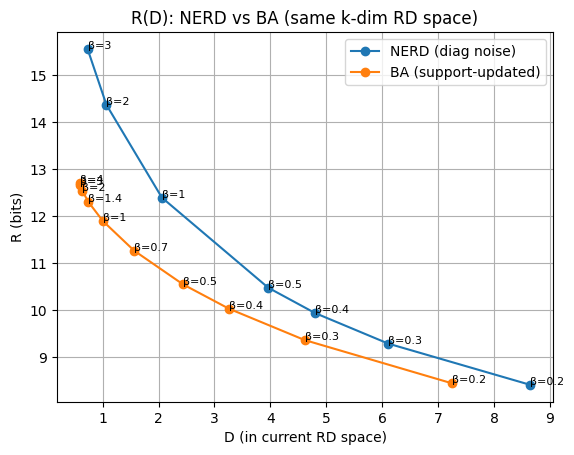

,beta,R_bits,D,ESS,mean_logg,K_components,steps,std_mode
0,0.2,8.408359,8.653826,165.370621,-7.558995,32768,2000,per_component
1,0.3,9.287918,6.110194,158.281616,-8.270952,32768,2000,per_component
2,0.4,9.940646,4.797320,175.731674,-8.809258,32768,2000,per_component
3,0.5,10.479702,3.960907,187.956940,-9.244430,32768,2000,per_component
4,1.0,12.398853,2.058903,144.117279,-10.653133,32768,2000,per_component
5,2.0,14.374331,1.066938,89.139130,-12.097403,32768,2000,per_component
6,3.0,15.566085,0.728967,71.033821,-12.976490,32768,2000,per_component


In [ ]:
# ============================================================
# NERD in k-dim RD space (matches corrected BA)
# Corrected:
#  - Removes all "floor" / "D_full(+floor)" logic
#  - Uses unambiguous distortion column name: D  (distortion in *current* RD space)
#  - BA overlay expects df_ba with columns ["beta","R_bits","D"] (from corrected BA code)
#  - Fixes a small device bug in training mini-batch sampling
# ============================================================

import math, time, numpy as np, pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

LN2 = math.log(2.0)

# ----------------------------
# 1) Closed-form integral for diagonal covariance
# ----------------------------
def chunk_logI_delta_diag(u, mu, sig, beta, need_delta=False):
    """
    logI(u,k) = log E_{y ~ N(mu_k, diag(sig_k^2))} exp(-beta ||u-y||^2)

    u  : (B,k)
    mu : (K,k)
    sig: (K,k)  std > 0

    Closed form:
      a = 1 + 2 beta sig^2   (K,k)
      logI = -0.5 sum_j log a_j  - beta * sum_j (u_j - mu_j)^2 / a_j
      delta = sum_j (u_j - mu_j)^2 / a_j^2  +  sum_j sig_j^2 / a_j
              (this is E[||u-y||^2 exp(-beta||u-y||^2)] / E[exp(-beta||u-y||^2)] componentwise-aggregated)
    """
    beta = float(beta)
    u = u.float()
    mu = mu.float()
    sig = sig.float()

    v = u[:, None, :] - mu[None, :, :]          # (B,K,k)
    s2 = sig * sig                              # (K,k)
    a = 1.0 + 2.0 * beta * s2                   # (K,k)
    inv_a = 1.0 / a                             # (K,k)

    q = (v * v * inv_a[None, :, :]).sum(-1)     # (B,K)
    logdet = torch.log(a).sum(-1)               # (K,)
    logI = -0.5 * logdet[None, :] - beta * q    # (B,K)

    if not need_delta:
        return logI, None

    inv_a2 = inv_a * inv_a                      # (K,k)
    delta = (v * v * inv_a2[None, :, :]).sum(-1) + (s2 * inv_a).sum(-1)[None, :]
    return logI, delta


# ----------------------------
# 2) NERD model in k-dim with diagonal noise
# ----------------------------
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.w = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x * x.pow(2).mean(-1, keepdim=True).add(self.eps).rsqrt() * self.w

class SwiGLUBlock(nn.Module):
    def __init__(self, h, mult=4.0, res_scale=1.0):
        super().__init__()
        self.norm = RMSNorm(h)
        f = int(h * mult)
        self.fc = nn.Linear(h, 2 * f)
        self.out = nn.Linear(f, h)
        self.rs = float(res_scale)
    def forward(self, x):
        y = self.norm(x)
        a, b = self.fc(y).chunk(2, -1)
        return x + self.rs * self.out(a * F.silu(b))

class Trunk(nn.Module):
    def __init__(self, z_dim, hidden, depth, mult=4.0):
        super().__init__()
        self.inp = nn.Linear(z_dim, hidden)
        rs = 1.0 / math.sqrt(max(1, depth))
        self.blocks = nn.ModuleList([SwiGLUBlock(hidden, mult, rs) for _ in range(depth)])
        self.norm = RMSNorm(hidden)
    def forward(self, z):
        x = self.inp(z)
        for b in self.blocks:
            x = b(x)
        return self.norm(x)

class NerdDiag(nn.Module):
    """
    NERD sampler in k-dim:
      z ~ N(0, I)
      component params: mu(z) in R^k, sig(z) in R^k (diagonal std)
    """
    def __init__(self, z_dim, k_dim, hidden=512, depth=4, mult=4.0,
                 min_std=1e-4, init_logsig=-4.0, std_mode="per_component"):
        super().__init__()
        self.z_dim = int(z_dim)
        self.k_dim = int(k_dim)
        self.min_std = float(min_std)
        self.std_mode = str(std_mode)

        self.trunk = Trunk(self.z_dim, hidden, depth, mult)
        self.mu_head = nn.Linear(hidden, self.k_dim)

        if self.std_mode == "per_component":
            self.logsig_head = nn.Linear(hidden, self.k_dim)
            nn.init.zeros_(self.logsig_head.weight)
            nn.init.constant_(self.logsig_head.bias, float(init_logsig))
            self.global_logsig = None
        elif self.std_mode == "global":
            self.logsig_head = None
            self.global_logsig = nn.Parameter(torch.full((self.k_dim,), float(init_logsig)))
        else:
            raise ValueError("std_mode must be 'per_component' or 'global'")

    def sample_z(self, K, device):
        return torch.randn(K, self.z_dim, device=device)

    def forward_components(self, z):
        h = self.trunk(z)
        mu = self.mu_head(h)
        if self.std_mode == "per_component":
            sig = F.softplus(self.logsig_head(h)) + self.min_std
        else:
            sig = F.softplus(self.global_logsig)[None, :].expand_as(mu) + self.min_std
        return mu, sig


# ----------------------------
# 3) Streaming estimators
# ----------------------------
def stream_logg_train_diag(model, u, beta, K, chunk_k=4096):
    """
    Differentiable streaming log g_beta(u) where
      g_beta(u) = E_{Y~Q_theta} exp(-beta||u-Y||^2)
    We estimate Q_theta by sampling K latent codes z and mapping -> (mu,sig).
    Returns logg(u) for each u in batch: (B,)
    """
    B = u.shape[0]
    m = torch.full((B,), -float("inf"), device=u.device)
    s1 = torch.zeros(B, device=u.device)

    for start in range(0, K, chunk_k):
        Kc = min(chunk_k, K - start)
        z = model.sample_z(Kc, u.device)
        with torch.amp.autocast("cuda", enabled=(u.device.type == "cuda"), dtype=torch.float16):
            mu, sig = model.forward_components(z)  # (Kc,k)
        logI, _ = chunk_logI_delta_diag(u, mu, sig, beta, need_delta=False)  # (B,Kc)

        cmax = logI.max(1).values
        m_new = torch.maximum(m, cmax)
        s1 = torch.exp(m - m_new) * s1 + torch.exp(logI - m_new.unsqueeze(1)).sum(1)
        m = m_new

    return torch.log(s1) + m - math.log(K)

@torch.no_grad()
def stream_eval_diag(model, u, beta, Z_components, chunk_k=4096):
    """
    Deterministic eval on fixed component grid Z_components (K,z_dim).
    Returns:
      D: distortion in current k-dim RD space
      R_bits: rate (bits)
      mean_logg: mean log g_beta(u)
      ESS: importance sampling ESS proxy (higher is better)
    """
    model.eval()
    u = u.float().to(Z_components.device)
    B, K = u.shape[0], Z_components.shape[0]

    m  = torch.full((B,), -float("inf"), device=Z_components.device)
    s1 = torch.zeros(B, device=Z_components.device)
    s2 = torch.zeros(B, device=Z_components.device)
    sd = torch.zeros(B, device=Z_components.device)

    for start in range(0, K, chunk_k):
        Kc = min(chunk_k, K - start)
        with torch.amp.autocast("cuda", enabled=(Z_components.device.type == "cuda"), dtype=torch.float16):
            mu, sig = model.forward_components(Z_components[start:start+Kc])
        logI, delta = chunk_logI_delta_diag(u, mu, sig, beta, need_delta=True)

        cmax = logI.max(1).values
        m_new = torch.maximum(m, cmax)
        r = torch.exp(m - m_new)
        e = torch.exp(logI - m_new.unsqueeze(1))

        s1 = s1 * r + e.sum(1)
        s2 = s2 * r * r + (e * e).sum(1)
        sd = sd * r + (e * delta).sum(1)
        m  = m_new

    logg = torch.log(s1) + m - math.log(K)   # (B,)
    D = float((sd / (s1 + 1e-12)).mean().item())
    mean_logg = float(logg.mean().item())
    R_bits = (-float(beta) * D - mean_logg) / LN2
    ess = float((s1 * s1 / (s2 + 1e-12)).mean().item())

    return {"D": D, "R_bits": R_bits, "mean_logg": mean_logg, "ess_mean": ess, "K": K}

def _fmt(tag, ev, loss=None):
    parts = [f"[{tag}]"]
    if loss is not None:
        parts.append(f"loss={loss:.4f}")
    parts += [f"D={ev['D']:.4f}", f"R={ev['R_bits']:.2f} bits", f"ESS={ev['ess_mean']:.1f}", f"logg={ev['mean_logg']:.4f}"]
    print(" | ".join(parts))


def train_nerd(
    model, beta, Z_train, Z_eval,
    steps=4000, lr=2e-4, wd=1e-4, clip=1.0,
    batch_u=1024, K=32768, chunk_k=4096, eval_every=250,
    Z_mon=None, device=None
):
    """
    Train NERD for fixed beta on Z_train (N,k) in the current RD space.
    """
    if device is None:
        device = next(model.parameters()).device

    Z_train = Z_train.to(device)
    Z_eval  = Z_eval.to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    if Z_mon is None:
        Z_mon = torch.randn(K, model.z_dim, device=device)

    ev0 = stream_eval_diag(model, Z_eval, beta, Z_mon, chunk_k=chunk_k)
    _fmt("init", ev0)

    t0 = time.time()
    for step in range(1, steps + 1):
        model.train()

        # sample mini-batch on device (fixes device mismatch)
        idx = torch.randint(0, Z_train.shape[0], (batch_u,), device=device)
        u = Z_train[idx]

        loss = -stream_logg_train_diag(model, u, beta, K, chunk_k=chunk_k).mean()

        opt.zero_grad(set_to_none=True)
        if device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            scaler.step(opt)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()

        if (step % eval_every == 0) or (step == steps):
            ev = stream_eval_diag(model, Z_eval, beta, Z_mon, chunk_k=chunk_k)
            _fmt(f"{step:5d}", ev, loss=float(loss.item()))

    print(f"Done beta={beta:g} in {(time.time()-t0)/60:.1f} min")
    ev_final = stream_eval_diag(model, Z_eval, beta, Z_mon, chunk_k=chunk_k)
    return model, ev_final


# ============================================================
# RUN: beta sweep + overlay vs BA if you have df_ba
# ============================================================

k_dim = Z_train.shape[1]
print(f"NERD will train in k={k_dim} dims. N_train={Z_train.shape[0]}, N_eval={Z_eval.shape[0]}")

# Hyperparams (same as yours)
Z_DIM    = 32
HIDDEN   = 512
DEPTH    = 4
MULT     = 4.0
STD_MODE = "per_component"   # or "global"

BETAS = [0.2, 0.3, 0.4, 0.5, 1.0, 2.0, 3.0]
STEPS_PER_BETA = 2000
EVAL_EVERY = 250
LR = 2e-4
WD = 1e-4
CLIP = 1.0
BATCH_U = 2048
K_COMP  = 32768
CHUNK_K = 4096

# Fixed eval component grid
Z_MON = torch.randn(K_COMP, Z_DIM, device=device)

model = NerdDiag(
    z_dim=Z_DIM, k_dim=k_dim,
    hidden=HIDDEN, depth=DEPTH, mult=MULT,
    min_std=1e-4, init_logsig=-4.0,
    std_mode=STD_MODE
).to(device)

rows = []
for i, beta in enumerate(BETAS):
    print("\n" + "="*72)
    print(f"NERD sweep {i+1}/{len(BETAS)}   beta={beta:g}")
    print("="*72)

    model, ev = train_nerd(
        model, beta,
        Z_train=Z_train,
        Z_eval=Z_eval,
        steps=STEPS_PER_BETA,
        lr=LR, wd=WD, clip=CLIP,
        batch_u=BATCH_U,
        K=K_COMP, chunk_k=CHUNK_K,
        eval_every=EVAL_EVERY,
        Z_mon=Z_MON,
        device=device
    )

    rows.append({
        "beta": float(beta),
        "R_bits": float(ev["R_bits"]),
        "D": float(ev["D"]),
        "ESS": float(ev["ess_mean"]),
        "mean_logg": float(ev["mean_logg"]),
        "K_components": int(ev["K"]),
        "steps": int(STEPS_PER_BETA),
        "std_mode": STD_MODE
    })

df_nerd = pd.DataFrame(rows)
print("\nNERD curve:")
print(df_nerd)

# ----------------------------
# Plot NERD and overlay BA (if df_ba exists)
# ----------------------------
plt.figure()

dfn = df_nerd.sort_values("D").reset_index(drop=True)
plt.plot(dfn["D"], dfn["R_bits"], marker="o", label="NERD (diag noise)")

for _, r in dfn.iterrows():
    plt.text(r["D"], r["R_bits"], f"β={r['beta']:g}", fontsize=8)

# BA overlay: expects df_ba with columns ["beta","R_bits","D"] (from corrected BA code)
try:
    df_ba_plot = df_ba.copy()
    assert all(c in df_ba_plot.columns for c in ["beta","R_bits","D"])
    df_ba_plot = df_ba_plot.sort_values("D").reset_index(drop=True)
    plt.plot(df_ba_plot["D"], df_ba_plot["R_bits"], marker="o", label="BA (support-updated)")
    for _, r in df_ba_plot.iterrows():
        plt.text(r["D"], r["R_bits"], f"β={r['beta']:g}", fontsize=8)
except Exception as e:
    print(f"[note] BA overlay skipped (need df_ba with columns beta,R_bits,D). ({e})")

plt.xlabel("D (in current RD space)")
plt.ylabel("R (bits)")
plt.title("R(D): NERD vs BA (same k-dim RD space)")
plt.grid(True)
plt.legend()
plt.show()

display(df_nerd)



In [ ]:
import torch, math

@torch.no_grad()
def vq_anchor_RD_from_Z(
    Z_eval: torch.Tensor,        # (N,k) in *final RD space*
    Z_codebook: torch.Tensor,    # (M,k) in *same RD space*
    batch_u: int = 8192,
    device=None,
    return_counts: bool = False,
):
    """
    VQ anchor in the current RD space:
      - Hard NN assignment to codebook in Z-space
      - D = E[min_m ||Z - Z_cb[m]||^2]
      - R = H(assignments) in bits (empirical entropy)

    Returns: dict with keys {D, R_bits, perplexity, usage_frac, (optional counts,p)}
    """
    if device is None:
        device = Z_eval.device

    Z = Z_eval.to(device).float()
    C = Z_codebook.to(device).float()

    N, k = Z.shape
    M = C.shape[0]
    assert C.shape[1] == k, f"Dim mismatch: Z_eval k={k}, Z_codebook k={C.shape[1]}"

    # Precompute codebook norms
    c2 = (C * C).sum(-1)  # (M,)

    counts = torch.zeros((M,), device=device, dtype=torch.long)
    total_min = 0.0

    for i in range(0, N, batch_u):
        z = Z[i:i+batch_u]                         # (B,k)
        z2 = (z * z).sum(-1, keepdim=True)         # (B,1)
        d = (z2 + c2[None, :] - 2.0 * (z @ C.t())).clamp(min=0.0)  # (B,M)

        min_val, min_idx = d.min(dim=1)            # (B,), (B,)
        total_min += float(min_val.sum().item())

        counts.scatter_add_(0, min_idx, torch.ones_like(min_idx, dtype=torch.long))

    D = total_min / float(N)

    p = counts.float() / counts.sum().clamp(min=1)
    p_nz = p[p > 0]
    R_bits = float((-(p_nz * torch.log2(p_nz)).sum()).item())
    perplexity = float(2.0 ** R_bits)
    usage_frac = float((counts > 0).float().mean().item())

    out = {
        "D": float(D),
        "R_bits": float(R_bits),
        "perplexity": perplexity,
        "usage_frac": usage_frac,
        "N": int(N),
        "M": int(M),
    }
    if return_counts:
        out["counts"] = counts.detach().cpu()
        out["p"] = p.detach().cpu()
    return out


# ---- Example call right after your PREP CELL ----
vq_anchor = vq_anchor_RD_from_Z(Z_eval, Z_codebook, batch_u=8192, device=device, return_counts=True)
print(f"[VQ anchor] D={vq_anchor['D']:.6f}   R={vq_anchor['R_bits']:.3f} bits"
      f"   perplexity={vq_anchor['perplexity']:.1f}   usage_frac={vq_anchor['usage_frac']:.3f}")



[VQ anchor] D=134.061342   R=7.840 bits   perplexity=229.1   usage_frac=0.323


In [ ]:
# ============================================================
# SIMPLE CELL: Run BA at beta=1 with M=8192, then pick 4096 codewords "properly"
#
# Goal:
#   - You want a 4096-size hard codebook for fair comparison with WavTokenizer VQ.
#   - BA with M=8192 at beta=1 typically yields an *effective* rate < log2(8192),
#     i.e. many support points have tiny mass q_j.
#   - The principled way to compress support to 4096 is: keep the 4096 points with
#     largest reproduction marginal probability q_j (highest usage under BA).
#     This preserves (approximately) the best-performing subset for that beta.
#
# Output:
#   - Y_BA_Z : [4096, k]   (codebook in FINAL Z space, ready for the eval cell)
#   - q_BA_4096 : [4096]   (their masses, renormalized)
#   - stats printed: R_bits (full 8192), entropy of 4096 subset, mass kept, etc.
#
# REQUIREMENTS:
#   - Z_eval : (N,k) in your chosen RD space (after applying W if REGIME='mel')
#   - ba_support, kmeanspp_init already defined (from your BA code)
# ============================================================

import math, torch

# ----------------------------
# USER SETTINGS
# ----------------------------
BETA = 5
M_FULL = 4096
M_KEEP = 4096
OUT_IT  = 20
IN_IT   = 8
CHUNK_N = 2048
INIT    = "kmeans++"
SEED    = 0

Z_src = Z_eval.to(device).float().contiguous()

# ----------------------------
# 1) Run BA at beta=1 with M=8192
# ----------------------------
print(f"[BA] beta={BETA}  M={M_FULL}  init={INIT}")

if INIT == "kmeans++":
    Y0 = kmeanspp_init(Z_src, M=M_FULL, seed=SEED, verbose=True)
else:
    idx = torch.randperm(Z_src.shape[0], device=device)[:M_FULL]
    Y0 = Z_src[idx].clone().contiguous()

out = ba_support(
    Z=Z_src,
    beta=float(BETA),
    M=M_FULL,
    Y_init=Y0,
    logq_init=None,
    outer_iters=OUT_IT,
    inner_iters=IN_IT,
    tol_q=1e-6,
    chunk_N=CHUNK_N,
    update_support=True,
    verbose=True,
)

Y_full = out["Y"].detach().contiguous()        # (8192,k)
q_full = out["q"].detach().contiguous()        # (8192,)
D_full = float(out["D"])
R_bits_full = float(out["R_bits"])

print(f"\n[BA full] D={D_full:.6f}  R={R_bits_full:.4f} bits")
print(f"[BA full] q stats: min={q_full.min().item():.3e}, median={q_full.median().item():.3e}, max={q_full.max().item():.3e}")

# ----------------------------
# 2) Compress support to 4096 by top-q (most used points)
# ----------------------------
# rationale: these are the highest posterior mass reproduction points at this beta.
vals, idx_top = torch.topk(q_full, k=M_KEEP, largest=True, sorted=True)

Y_BA_Z = Y_full[idx_top].contiguous()          # (4096,k)
q_BA_4096 = vals / vals.sum()                  # renormalize masses over kept points

mass_kept = float(vals.sum().item())
print(f"\n[keep top-q] kept_mass={mass_kept:.6f} (should be close to 1 if tail is tiny)")

# entropy/perplexity of the kept subset (this is a "hard-ish" effective support size indicator)
H_keep = float((-(q_BA_4096 * torch.log2(q_BA_4096 + 1e-30))).sum().item())
print(f"[keep top-q] entropy(q_keep)={H_keep:.4f} bits  perplexity={2**H_keep:.1f}")

# ----------------------------
# 3) Optional: refine q on the fixed 4096 support (no centroid moves)
#    This makes q consistent with the reduced support for this beta.
# ----------------------------
print("\n[refit q on fixed 4096 support] (optional but recommended)")
out_fix = ba_support(
    Z=Z_src,
    beta=float(BETA),
    M=M_KEEP,
    Y_init=Y_BA_Z,
    logq_init=torch.log(q_BA_4096 + 1e-30),
    outer_iters=6,          # few outer loops is enough since support is fixed
    inner_iters=20,
    tol_q=1e-7,
    chunk_N=CHUNK_N,
    update_support=False,   # FIXED support!
    verbose=False,
)

Y_BA_Z = out_fix["Y"].detach().contiguous()     # unchanged
q_BA_4096 = out_fix["q"].detach().contiguous()
D_keep = float(out_fix["D"])
R_bits_keep = float(out_fix["R_bits"])

print(f"[fixed-4096] D={D_keep:.6f}  R={R_bits_keep:.4f} bits")

# expose these for the next eval cell
#   - Y_BA_Z is the BA codebook in FINAL Z space (4096,k)
#   - q_BA_4096 are the BA masses (4096,)
print("\n[done] Exported: Y_BA_Z (4096,k), q_BA_4096 (4096,)")


[BA] beta=5  M=4096  init=kmeans++
kmeans++ init: picked 512/4096 centers
kmeans++ init: picked 1024/4096 centers
kmeans++ init: picked 1536/4096 centers
kmeans++ init: picked 2048/4096 centers
kmeans++ init: picked 2560/4096 centers
kmeans++ init: picked 3072/4096 centers
kmeans++ init: picked 3584/4096 centers
[outer 00] beta=5  D=0.322112  R=10.2705 bits  max|Δq|=7.04e-05
[outer 01] beta=5  D=0.268877  R=10.3526 bits  max|Δq|=1.94e-05
[outer 02] beta=5  D=0.255490  R=10.3863 bits  max|Δq|=1.64e-05
[outer 03] beta=5  D=0.249041  R=10.4044 bits  max|Δq|=1.45e-05
[outer 04] beta=5  D=0.245236  R=10.4156 bits  max|Δq|=9.53e-06
[outer 05] beta=5  D=0.242694  R=10.4237 bits  max|Δq|=7.98e-06
[outer 06] beta=5  D=0.240821  R=10.4299 bits  max|Δq|=6.43e-06
[outer 07] beta=5  D=0.239447  R=10.4349 bits  max|Δq|=5.61e-06
[outer 08] beta=5  D=0.238345  R=10.4391 bits  max|Δq|=4.47e-06
[outer 09] beta=5  D=0.237410  R=10.4428 bits  max|Δq|=6.00e-06
[outer 10] beta=5  D=0.236619  R=10.4459 bits 

In [ ]:
# ============================================================
# CORRECT EVAL CELL: BA vs VQ on *true decode* log-mel distortion
#   - Choose nearest codeword in Z-space for both
#   - Decode:
#       VQ: use TRUE codebook vector (normalized 512D)
#       BA: map Z -> u_norm (512D) via inverse transform
#   - Compare log-mel MSE to reference decode (no quantization)
# ============================================================

import torch
import torch.nn.functional as F
import torchaudio
import math
from tqdm import tqdm

assert "Y_BA_Z" in globals(), "Define Y_BA_Z (BA codebook in FINAL Z space) before running."
assert "Z_codebook" in globals(), "Z_codebook not found. Run PREP cell to create it."
assert "codebook" in globals(), "codebook not found."
assert "U_eval_n" in globals(), "U_eval_n not found."
assert "B_pca" in globals() and "mu_pca" in globals() and "W" in globals(), "Need B_pca, mu_pca, W from PREP."
assert "u_mean" in globals() and "u_std" in globals(), "Need u_mean/u_std from latent collection."
assert "wavtokenizer" in globals(), "Need wavtokenizer loaded."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Inputs
# ----------------------------
Y_BA_Z = Y_BA_Z.to(device).float().contiguous()          # (M_ba, k)
Z_codebook = Z_codebook.to(device).float().contiguous()  # (4096, k)

print("[eval] Y_BA_Z:", tuple(Y_BA_Z.shape), "Z_codebook:", tuple(Z_codebook.shape))

# ----------------------------
# Forward/inverse map u_norm <-> Z_final
# ----------------------------
B = B_pca.to(device).float()        # (512,k)
mu = mu_pca.to(device).float()      # (512,)
Wk = W.to(device).float()           # (k,k)
WinvT = torch.linalg.inv(Wk).t().contiguous()  # (k,k)  z_pca = z_final @ WinvT

u_mean_d = u_mean.to(device).float()
u_std_d  = u_std.to(device).float()

@torch.no_grad()
def u_norm_to_z_final(u_norm_512: torch.Tensor) -> torch.Tensor:
    # u_norm_512: (512,) or (B,512)
    if u_norm_512.dim() == 1:
        u_norm_512 = u_norm_512[None, :]
    Z_pca = (u_norm_512 - mu) @ B            # (B,k)
    Z_fin = Z_pca @ Wk.t()                   # (B,k)
    return Z_fin

@torch.no_grad()
def z_final_to_u_norm(z_fin_k: torch.Tensor) -> torch.Tensor:
    # z_fin_k: (k,) or (B,k)
    if z_fin_k.dim() == 1:
        z_fin_k = z_fin_k[None, :]
    z_pca = z_fin_k @ WinvT                  # (B,k)
    u_norm = mu + z_pca @ B.t()              # (B,512)
    return u_norm

# ----------------------------
# TRUE VQ codebook in normalized 512D (project_in coords)
# ----------------------------
@torch.no_grad()
def get_codebook_u_norm(codebook_512: torch.Tensor) -> torch.Tensor:
    # codebook is in the SAME 512D space as captured u (project_in output)
    cb = codebook_512.to(device).float()
    cb_n = (cb - u_mean_d) / u_std_d
    return cb_n.contiguous()  # (4096,512)

CB_U_NORM = get_codebook_u_norm(codebook)  # (4096,512)

# ----------------------------
# Nearest neighbor in Z-space
# ----------------------------
@torch.no_grad()
def nearest_code_idx(z_fin: torch.Tensor, C_fin: torch.Tensor):
    """
    z_fin: (B,k), C_fin: (M,k)
    returns idx: (B,), dmin: (B,)
    """
    z = z_fin.float()
    C = C_fin.float()
    z2 = (z*z).sum(-1, keepdim=True)            # (B,1)
    c2 = (C*C).sum(-1).view(1, -1)              # (1,M)
    d = (z2 + c2 - 2.0*(z @ C.t())).clamp(min=0.0)  # (B,M)
    dmin, idx = d.min(dim=1)
    return idx, dmin

# ----------------------------
# Decoder wrapper (NO grads)
# ----------------------------
decoder = wavtokenizer.feature_extractor.encodec.decoder
vq0 = wavtokenizer.feature_extractor.encodec.quantizer.vq.layers[0]

@torch.no_grad()
def decode_from_u_norm_seq(u_norm_seq):
    """
    u_norm_seq: [1, T, 512] in normalized project_in coords
    returns wav: [1, 1, T_audio]
    """
    u = u_norm_seq * u_std_d + u_mean_d       # unnormalize -> project_in coords
    u_out = vq0.project_out(u)                # -> decoder coords
    z = u_out.transpose(1, 2).contiguous()    # [1,512,T]
    wav = decoder(z)                          # [1,1,T_audio]
    return wav

@torch.no_grad()
def splice_center(u_ctx, u_center_512, t):
    # u_ctx: [1,T,512], u_center_512: [512]
    return torch.cat([u_ctx[:, :t, :], u_center_512.view(1,1,-1), u_ctx[:, t+1:, :]], dim=1)

# ----------------------------
# Log-mel MSE
# ----------------------------
TARGET_SR = int(TARGET_SR)

mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=TARGET_SR,
    n_fft=1024,
    hop_length=256,
    n_mels=80,
    f_min=0.0,
    f_max=TARGET_SR/2,
    power=2.0,
).to(device)

if hasattr(mel, "spectrogram") and hasattr(mel.spectrogram, "window"):
    mel.spectrogram.window = mel.spectrogram.window.to(device)

@torch.no_grad()
def logmel(x):  # x: [1,1,T]
    w = x[:, 0, :]                 # [1,T]
    M = mel(w)                     # [1,80,frames]
    return torch.log(M + 1e-6)

@torch.no_grad()
def logmel_mse(x, y):
    return F.mse_loss(logmel(x), logmel(y), reduction="mean")

# ----------------------------
# Main evaluation (returns means + dispersions)
# ----------------------------
@torch.no_grad()
def eval_codebooks_on_contexts(
    U_eval_n_cpu: torch.Tensor,    # (N,512) normalized frames (can be CPU)
    Z_vq: torch.Tensor,            # (4096,k) FINAL Z coords of VQ codebook (from PREP)
    Z_ba: torch.Tensor,            # (M_ba,k) FINAL Z coords of BA codebook
    CB_u_norm: torch.Tensor,       # (4096,512) TRUE VQ codewords in normalized 512D
    T_ctx: int = 15,
    t_target: int = None,
    n_contexts: int = 200,
    seed: int = 0,
):
    if t_target is None:
        t_target = T_ctx // 2
    assert U_eval_n_cpu.dim() == 2 and U_eval_n_cpu.shape[1] == 512
    N = U_eval_n_cpu.shape[0]
    assert N > T_ctx + 5

    g = torch.Generator(device="cpu")
    g.manual_seed(int(seed))
    starts = torch.randint(0, N - T_ctx - 1, (n_contexts,), generator=g, device="cpu").tolist()

    mel_vq_list = []
    mel_ba_list = []
    Dz_vq_list  = []
    Dz_ba_list  = []

    used_vq = torch.zeros(Z_vq.shape[0], device=device, dtype=torch.long)
    used_ba = torch.zeros(Z_ba.shape[0], device=device, dtype=torch.long)

    for s in tqdm(starts):
        u_ctx = U_eval_n_cpu[s:s+T_ctx].unsqueeze(0).to(device).float()  # [1,T,512]
        u_t   = u_ctx[0, t_target, :].contiguous()                       # [512]

        wav_ref = decode_from_u_norm_seq(u_ctx)

        z_t = u_norm_to_z_final(u_t)                                     # [1,k]

        # --- VQ ---
        idx_vq, d_vq = nearest_code_idx(z_t, Z_vq)                       # (1,), (1,)
        idx_vq_i = int(idx_vq.item())
        used_vq[idx_vq_i] += 1

        uhat_vq = CB_u_norm[idx_vq_i]                                    # TRUE VQ codeword (512,)
        wav_vq = decode_from_u_norm_seq(splice_center(u_ctx, uhat_vq, t_target))

        # --- BA ---
        idx_ba, d_ba = nearest_code_idx(z_t, Z_ba)
        idx_ba_i = int(idx_ba.item())
        used_ba[idx_ba_i] += 1

        y_ba = Z_ba[idx_ba_i]                                            # (k,)
        uhat_ba = z_final_to_u_norm(y_ba)[0]                              # (512,)
        wav_ba = decode_from_u_norm_seq(splice_center(u_ctx, uhat_ba, t_target))

        mel_vq_list.append(float(logmel_mse(wav_vq, wav_ref).item()))
        mel_ba_list.append(float(logmel_mse(wav_ba, wav_ref).item()))
        Dz_vq_list.append(float(d_vq.item()))
        Dz_ba_list.append(float(d_ba.item()))

    mel_vq_t = torch.tensor(mel_vq_list)
    mel_ba_t = torch.tensor(mel_ba_list)
    Dz_vq_t  = torch.tensor(Dz_vq_list)
    Dz_ba_t  = torch.tensor(Dz_ba_list)

    def entropy_bits(counts):
        p = counts.float() / counts.sum().clamp(min=1.0)
        p = p[p > 0]
        return float((-(p * torch.log2(p)).sum()).item())

    def summarize(x):
        x = x.float()
        mean = float(x.mean().item())
        std  = float(x.std(unbiased=True).item()) if len(x) > 1 else 0.0
        sem  = std / math.sqrt(max(1, len(x)))
        return mean, std, sem

    mel_vq_mean, mel_vq_std, mel_vq_sem = summarize(mel_vq_t)
    mel_ba_mean, mel_ba_std, mel_ba_sem = summarize(mel_ba_t)
    Dz_vq_mean,  Dz_vq_std,  Dz_vq_sem  = summarize(Dz_vq_t)
    Dz_ba_mean,  Dz_ba_std,  Dz_ba_sem  = summarize(Dz_ba_t)

    Hvq = entropy_bits(used_vq)
    Hba = entropy_bits(used_ba)

    return {
        "n_contexts": int(n_contexts),
        "T_ctx": int(T_ctx),
        "t_target": int(t_target),

        "melMSE_vq_vs_ref_mean": mel_vq_mean,
        "melMSE_vq_vs_ref_std":  mel_vq_std,
        "melMSE_vq_vs_ref_sem":  mel_vq_sem,

        "melMSE_ba_vs_ref_mean": mel_ba_mean,
        "melMSE_ba_vs_ref_std":  mel_ba_std,
        "melMSE_ba_vs_ref_sem":  mel_ba_sem,

        "Dz_vq_mean": Dz_vq_mean,
        "Dz_vq_std":  Dz_vq_std,
        "Dz_vq_sem":  Dz_vq_sem,

        "Dz_ba_mean": Dz_ba_mean,
        "Dz_ba_std":  Dz_ba_std,
        "Dz_ba_sem":  Dz_ba_sem,

        "Rbits_vq_entropy": Hvq,
        "Rbits_ba_entropy": Hba,

        "perplex_vq": float(2.0 ** Hvq),
        "perplex_ba": float(2.0 ** Hba),
    }

# ----------------------------
# RUN
# ----------------------------
T_CTX = 15
t_target = T_CTX // 2
N_CONTEXTS = 10000   # increase to 500–2000 for tighter SE

res = eval_codebooks_on_contexts(
    U_eval_n_cpu=U_eval_n,        # keep CPU is fine
    Z_vq=Z_codebook,
    Z_ba=Y_BA_Z,
    CB_u_norm=CB_U_NORM,
    T_ctx=T_CTX,
    t_target=t_target,
    n_contexts=N_CONTEXTS,
    seed=0,
)

print("\n=== BA vs VQ on *true decode* log-mel distortion (vs ref decode) ===")
for k, v in res.items():
    print(f"{k:>28s}: {v}")



[eval] Y_BA_Z: (4096, 5) Z_codebook: (4096, 5)


100%|██████████| 10000/10000 [02:53<00:00, 57.73it/s]


=== BA vs VQ on *true decode* log-mel distortion (vs ref decode) ===
                  n_contexts: 10000
                       T_ctx: 15
                    t_target: 7
       melMSE_vq_vs_ref_mean: 0.005350626539438963
        melMSE_vq_vs_ref_std: 0.0013224638532847166
        melMSE_vq_vs_ref_sem: 1.3224638532847166e-05
       melMSE_ba_vs_ref_mean: 0.004589788615703583
        melMSE_ba_vs_ref_std: 0.001075603999197483
        melMSE_ba_vs_ref_sem: 1.075603999197483e-05
                  Dz_vq_mean: 0.46143731474876404
                   Dz_vq_std: 0.5539063215255737
                   Dz_vq_sem: 0.005539063215255737
                  Dz_ba_mean: 0.14269936084747314
                   Dz_ba_std: 0.11889908462762833
                   Dz_ba_sem: 0.0011889908462762832
            Rbits_vq_entropy: 10.571252822875977
            Rbits_ba_entropy: 11.408716201782227
                  perplex_vq: 1521.4727955581964
                  perplex_ba: 2718.728180044199
